In [ ]:
import boto3
import sagemaker
from sklearn.model_selection import train_test_split
import pandas as pd

sm_boto3 = boto3.client('sagemaker')
bucket = 'sentongo-sagemaker'
region = 'us-east-2'  # Bucket is in us-east-2
print("Using bucket: " + bucket + " in region: " + region)

[03/10/26 22:14:28] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=706542;file://c:\Users\sento\anaconda3\Lib\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=4820;file://c:\Users\sento\anaconda3\Lib\site-packages\botocore\credentials.py#1392\1392]8;;\

Using bucket: sentongo-sagemaker in region: us-east-1


In [11]:
# Load the datasets
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
print("\nTrain data columns:", list(train_data.columns))
print("\nTest data columns:", list(test_data.columns))

Train data shape: (2000, 21)
Test data shape: (1000, 21)

Train data columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']

Test data columns: ['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


In [12]:
# Check data types and missing values
print("Train data info:")
train_data.info()
print("\nMissing values in train data:")
print(train_data.isnull().sum())
print("\nMissing values in test data:")
print(test_data.isnull().sum())

Train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int6

In [13]:
# Descriptive statistics
print("Train data descriptive statistics:")
train_data.describe()

Train data descriptive statistics:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


[10/03/2026 22:17:35] INFO     Using categorical units to plot a list of strings that are all       ]8;id=531726;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=277550;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=589102;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=876607;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

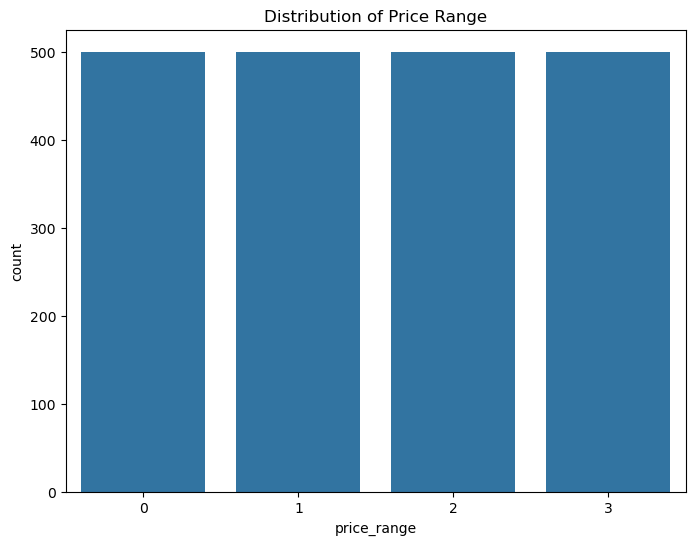

Price range counts:
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [14]:
# Target variable distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='price_range', data=train_data)
plt.title('Distribution of Price Range')
plt.show()

print("Price range counts:")
print(train_data['price_range'].value_counts())

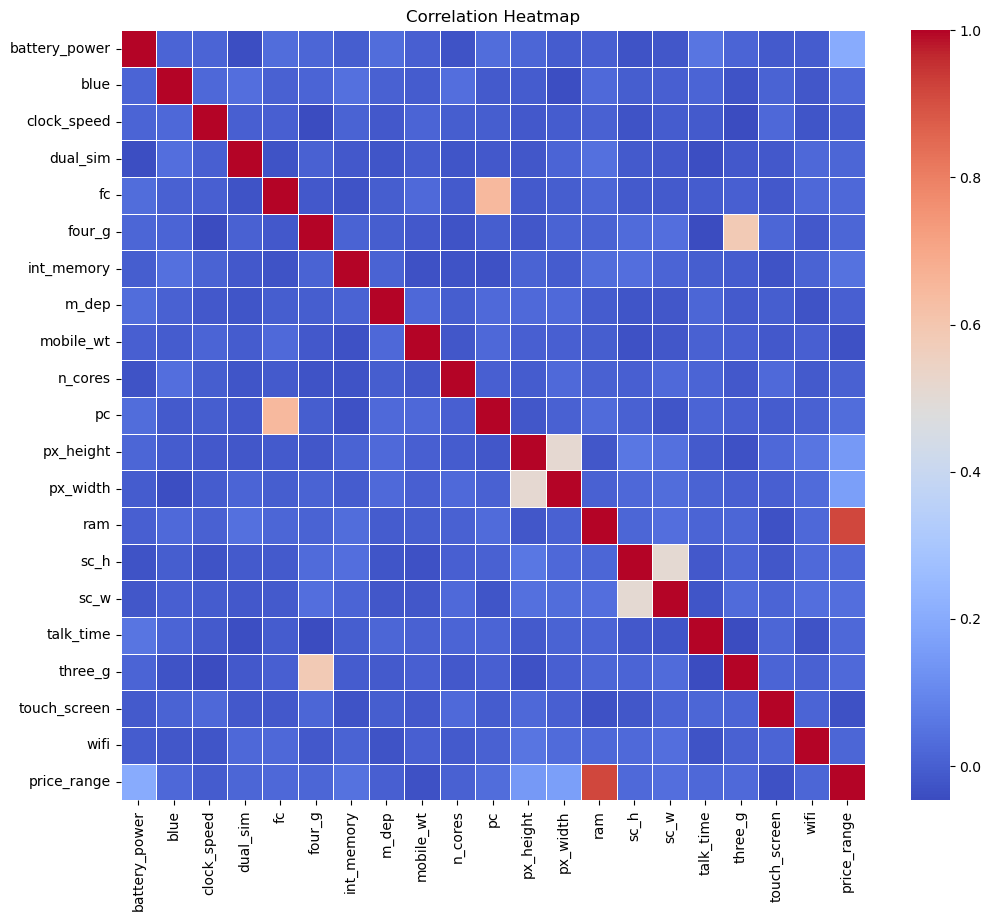

Correlation with price_range:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [15]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = train_data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Correlation with target
print("Correlation with price_range:")
print(train_data.corr()['price_range'].sort_values(ascending=False))

[10/03/2026 22:17:48] INFO     Using categorical units to plot a list of strings that are all       ]8;id=37114;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=803949;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=172466;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=221390;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=543790;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=945763;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=56695;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=756910;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=637509;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=263491;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=159045;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=645314;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=72197;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=418163;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

                      INFO     Using categorical units to plot a list of strings that are all       ]8;id=362763;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=98729;file://c:\Users\sento\anaconda3\Lib\site-packages\matplotlib\category.py#224\224]8;;\
                               parsable as floats or dates. If these strings should be plotted as                  
                               numbers, cast to the appropriate data type before plotting.                         

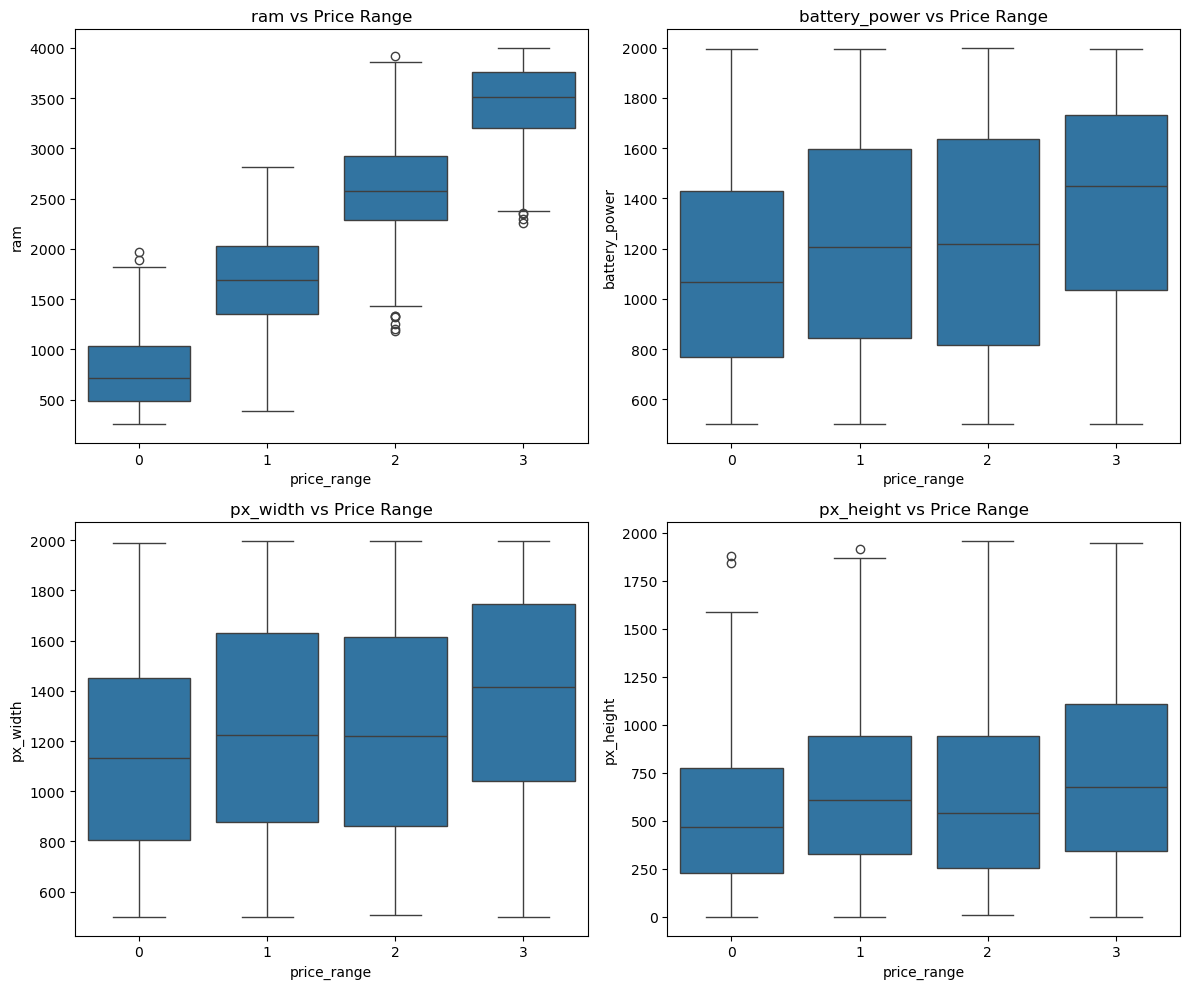

In [16]:
# Boxplots for key features vs price_range
key_features = ['ram', 'battery_power', 'px_width', 'px_height']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feature in enumerate(key_features):
    ax = axes[i//2, i%2]
    sns.boxplot(x='price_range', y=feature, data=train_data, ax=ax)
    ax.set_title(f'{feature} vs Price Range')
plt.tight_layout()
plt.show()

In [17]:
# Feature selection and data preparation
# All features are numerical and relevant based on EDA
X = train_data.drop('price_range', axis=1)
y = train_data['price_range']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Feature names:", list(X.columns))

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

# Prepare test data (without target)
X_test = test_data.drop('id', axis=1)  # Remove id column
test_ids = test_data['id']

print("Test set shape:", X_test.shape)

Features (X) shape: (2000, 20)
Target (y) shape: (2000,)
Feature names: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']
Train set shape: (1600, 20) (1600,)
Validation set shape: (400, 20) (400,)
Test set shape: (1000, 20)


In [18]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (1600, 20)
Scaled val shape: (400, 20)
Scaled test shape: (1000, 20)


In [20]:
# Train a baseline model (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_val = rf_model.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance.head(10))

Validation Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400


Top 10 Feature Importances:
          feature  importance
13            ram    0.480768
0   battery_power    0.072976
12       px_width    0.056089
11      px_height    0.056000
8       mobile_wt    0.039007
6      int_memory    0.034837
16      talk_time    0.031891
10             pc    0.029158
2     clock_speed    0.028857
15           sc_w    0.027847


In [33]:
# Train model on SageMaker using XGBoost
from sagemaker import image_uris
from sagemaker.session import Session as SageSession
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator

# SageMaker session
sagemaker_session = SageSession(boto_session=boto3.Session(region_name=region))

# Get XGBoost container
xgboost_container = image_uris.retrieve('xgboost', region, '1.5-1')

# Define estimator - REPLACE THE ROLE ARN WITH YOUR ACTUAL SAGEMAKER EXECUTION ROLE
xgb = Estimator(
    image_uri=xgboost_container,
    role='arn:aws:iam::YOUR_ACCOUNT_ID:role/SageMakerExecutionRole',  # Replace with your actual role ARN
    instance_count=1,
    instance_type='ml.m5.large',
    output_path=f's3://{bucket}/mobile-price/output',
    sagemaker_session=sagemaker_session
)

# Set hyperparameters
xgb.set_hyperparameters(
    objective='multi:softmax',
    num_class=4,
    num_round=100,
    max_depth=5,
    eta=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8
)

# Define data channels
train_input = TrainingInput(f's3://{bucket}/mobile-price/train/train.csv', content_type='csv')
val_input = TrainingInput(f's3://{bucket}/mobile-price/validation/validation.csv', content_type='csv')

# Train the model
xgb.fit({'train': train_input, 'validation': val_input})

print("Model training completed.")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│    1 # Train model on SageMaker using XGBoost                                                    │
│ ❱  2 from sagemaker import image_uris                                                            │
│    3 from sagemaker.session import Session as SageSession                                        │
│    4 from sagemaker.inputs import TrainingInput                                                  │
│    5 from sagemaker.estimator import Estimator                                                   │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ImportError: cannot import name 'image_uris' from 'sagemaker' 
(c:\Users\sento\anaconda3\Lib\site-packages\sagemaker\__init__.py)

In [31]:
# Make predictions on test data using the trained model
y_pred_test = rf_model.predict(X_test_scaled)

# Create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'price_range': y_pred_test
})

print("Predictions completed.")
print("Sample predictions:")
print(submission.head())

# Save predictions to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file saved as submission.csv")

Predictions completed.
Sample predictions:
   id  price_range
0   1            3
1   2            3
2   3            2
3   4            3
4   5            1
Submission file saved as submission.csv


In [24]:
# Check if bucket exists, create if not
s3 = boto3.client('s3')
try:
    s3.head_bucket(Bucket=bucket)
    print(f"Bucket {bucket} exists.")
except:
    s3.create_bucket(Bucket=bucket, CreateBucketConfiguration={'LocationConstraint': region})
    print(f"Bucket {bucket} created in {region}.")

Bucket sentongo-sagemaker exists.


In [26]:
# Get bucket location
location = s3.get_bucket_location(Bucket=bucket)
print("Bucket location:", location.get('LocationConstraint', 'us-east-1'))

Bucket location: us-east-2


In [32]:
# Prepare data for SageMaker - save as CSV without headers, label first
import os

# Create directories
os.makedirs('data/train', exist_ok=True)
os.makedirs('data/validation', exist_ok=True)
os.makedirs('data/test', exist_ok=True)

# Save training data (label first, no headers)
train_df = pd.DataFrame(X_train_scaled)
train_df.insert(0, 'label', y_train.values)
train_df.to_csv('data/train/train.csv', index=False, header=False)

# Save validation data
val_df = pd.DataFrame(X_val_scaled)
val_df.insert(0, 'label', y_val.values)
val_df.to_csv('data/validation/validation.csv', index=False, header=False)

# Save test data (no label, for prediction)
test_df = pd.DataFrame(X_test_scaled)
test_df.to_csv('data/test/test.csv', index=False, header=False)

print("CSV files created successfully.")

# Upload to S3 with correct region
s3 = boto3.client('s3', region_name=region)
s3.upload_file('data/train/train.csv', bucket, 'mobile-price/train/train.csv')
s3.upload_file('data/validation/validation.csv', bucket, 'mobile-price/validation/validation.csv')
s3.upload_file('data/test/test.csv', bucket, 'mobile-price/test/test.csv')

print("Data uploaded to S3 successfully.")

CSV files created successfully.
Data uploaded to S3 successfully.
